In [ ]:
## From: 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [20]:
# 加载 California 房价数据集,它从网络下载（或从本地缓存读取）加州 1990 年人口普查数据，返回一个类似字典的对象。
# as_frame=True 直接得到 pandas DataFrame
housing = fetch_california_housing(as_frame=True)
print(type(housing))

# 包含特征 + 目标列的完整 DataFrame
data = housing.frame
# 打印数据基本信息
print("数据集维度：", data.shape)
print("数据集特征：\n", data.columns)


<class 'sklearn.utils._bunch.Bunch'>
数据集维度： (20640, 9)
数据集特征：
 Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


In [15]:
housing

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude 

In [12]:
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [23]:
# 选择特征与目标变量
X = data.drop("MedHouseVal", axis=1)  # 房屋中位数作为目标变量
y = data["MedHouseVal"]
X
y
# 将数据集拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# 初始化 KNN 回归器
knn = KNeighborsRegressor()

# 设置超参数搜索空间：邻居数从 1 到 30
param_grid = {'n_neighbors': np.arange(1, 31)}

# 使用 GridSearchCV 进行超参数优化，采用 5 折交叉验证
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])},
             scoring='neg_mean_squared_error')

In [25]:
# 输出最优参数与对应的得分
best_k = grid_search.best_params_['n_neighbors']
best_score = -grid_search.best_score_
print("最优邻居数 k =", best_k)
print("最佳均方误差 (MSE) =", best_score)

# 使用最优参数训练模型
best_knn = grid_search.best_estimator_
best_knn.fit(X_train, y_train)


最优邻居数 k = 9
最佳均方误差 (MSE) = 1.1463744042292974


KNeighborsRegressor(n_neighbors=np.int64(9))

In [26]:
# 在测试集上进行预测
y_pred = best_knn.predict(X_test)

# 计算测试集上的 MSE 和 R2 分数
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("测试集均方误差 (MSE) =", mse)
print("测试集 R2 score =", r2)# 在测试集上进行预测
y_pred = best_knn.predict(X_test)

# 计算测试集上的 MSE 和 R2 分数
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("测试集均方误差 (MSE) =", mse)
print("测试集 R2 score =", r2)

测试集均方误差 (MSE) = 1.103251681789815
测试集 R2 score = 0.1580859868109067
测试集均方误差 (MSE) = 1.103251681789815
测试集 R2 score = 0.1580859868109067


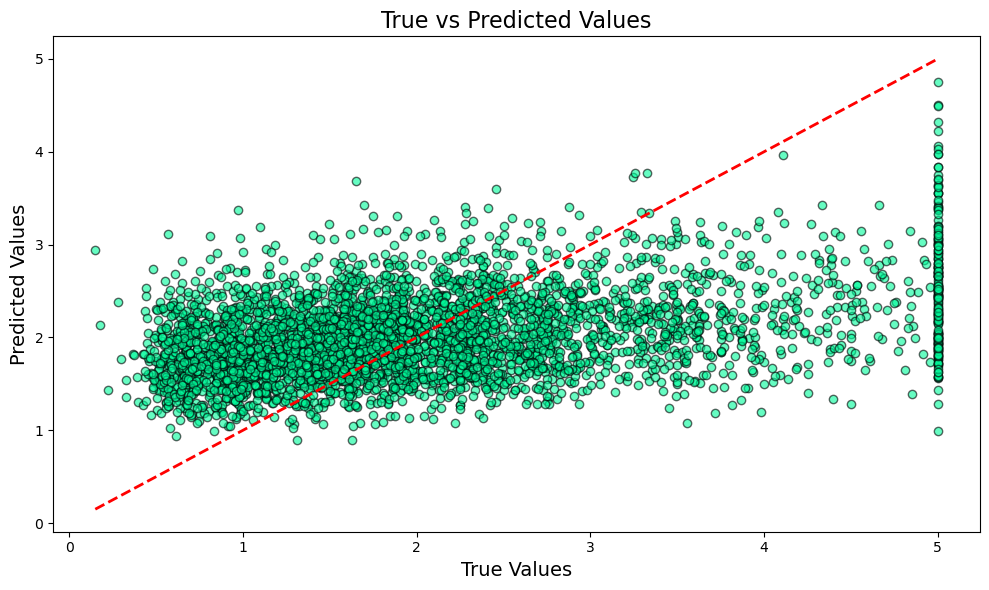

In [27]:
# 可视化：真实值 vs 预测值
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='mediumspringgreen', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("True Values", fontsize=14)
plt.ylabel("Predicted Values", fontsize=14)
plt.title("True vs Predicted Values", fontsize=16)
plt.tight_layout()
plt.show()

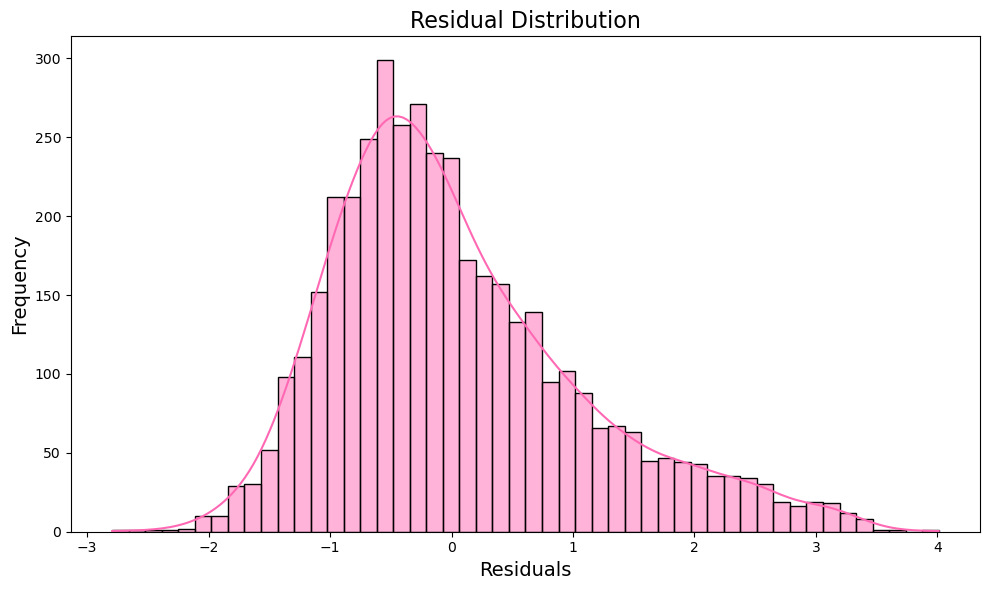

In [28]:
# 可视化：残差分布
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True, color='hotpink')
plt.xlabel("Residuals", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Residual Distribution", fontsize=16)
plt.tight_layout()
plt.show()

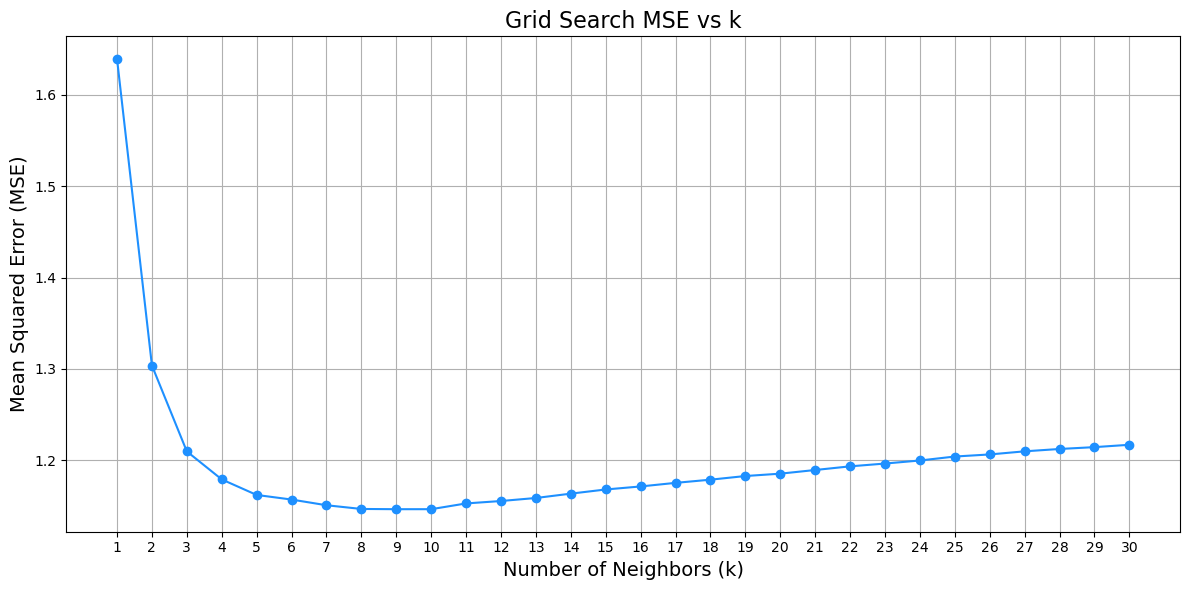

In [32]:
# 可视化：GridSearchCV 中不同 k 值的均方误差热力图
# 提取所有搜索结果
results = pd.DataFrame(grid_search.cv_results_)
results['mean_test_mse'] = -results['mean_test_score']

plt.figure(figsize=(12, 6))
plt.plot(results['param_n_neighbors'], results['mean_test_mse'], marker='o', linestyle='-', color='dodgerblue')
plt.xlabel("Number of Neighbors (k)", fontsize=14)
plt.ylabel("Mean Squared Error (MSE)", fontsize=14)
plt.title("Grid Search MSE vs k", fontsize=16)
plt.xticks(results['param_n_neighbors'])
plt.grid(True)
plt.tight_layout()
plt.show()